In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Pyplot - The part which draws the plots
#Matplotlib - The big library which contains pyplot
#plt - nickname for pyplot

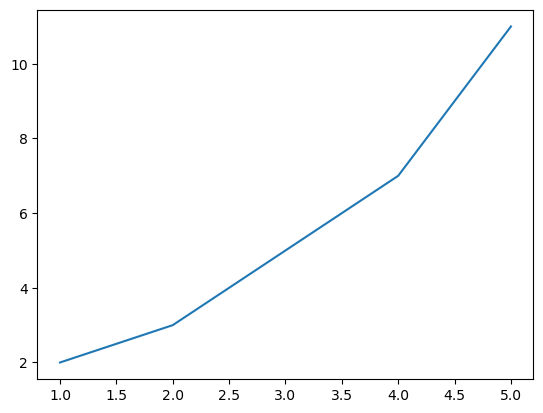

In [2]:
#Now lets understand some basic plotting functions in pyplot
x = [1,2,3,4,5]  #horizontal values
y = [2,3,5,7,11] #vertical values
plt.plot(x,y)    #plot y against x
plt.show()       #display the plot

In [3]:
#plot → draw line
#bar → draw bars
#hist → group values
#scatter → draw dots
#pie → draw pie chart
#box → draw box plot

In [4]:
data = pd.read_csv(r"C:\Users\NewUser\Downloads\Video_Games_Sales_as_at_22_Dec_2016.csv")
data.head() 

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [6]:
data.shape

(16719, 16)

In [7]:
data.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [8]:
data["Year_of_Release"].dtypes

dtype('float64')

In [9]:
data["Year_of_Release"].astype("Int64")

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16714    2016
16715    2006
16716    2016
16717    2003
16718    2016
Name: Year_of_Release, Length: 16719, dtype: Int64

<Axes: xlabel='Year_of_Release'>

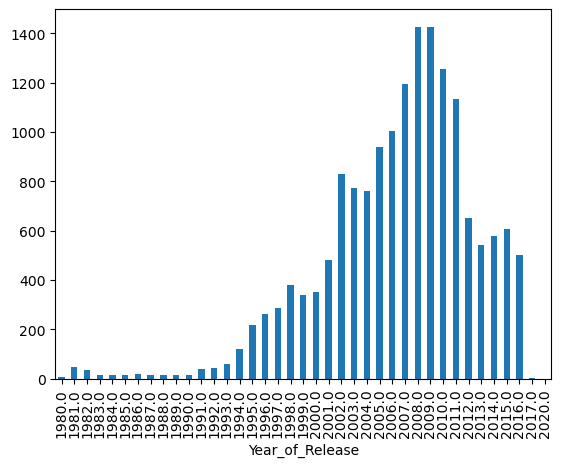

In [10]:
data["Year_of_Release"].value_counts().sort_index().plot(kind='bar')

In [24]:
data.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

In [12]:
data.dropna(inplace = True)

In [13]:
data.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

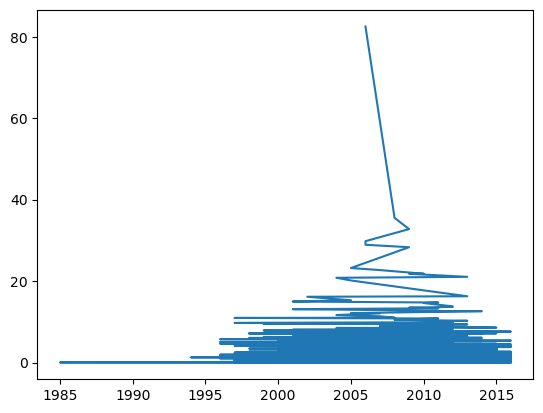

In [14]:
plt.plot(data["Year_of_Release"], data["Global_Sales"]) #your first plot 
plt.show()  #it is like print statement. without this you won't see the plot

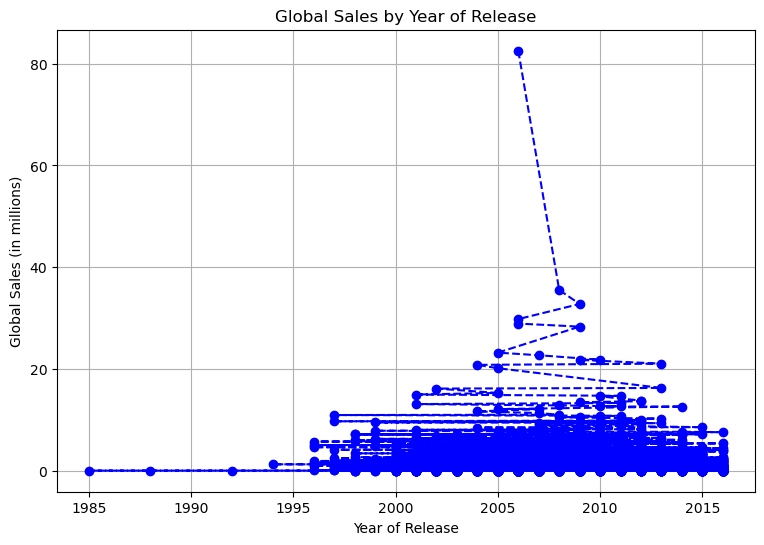

In [15]:
#This is same Plot but cleaner and better version of it
plt.figure(figsize=(9,6))  #Canvas Size - Like a Matrix 
plt.plot(data["Year_of_Release"], data["Global_Sales"], marker='o', linestyle='--', color='b') #your first plot - by default line plot
plt.title("Global Sales by Year of Release") #Title of the plot
plt.xlabel("Year of Release") #X-axis Label
plt.ylabel("Global Sales (in millions)") #Y-axis Label
plt.grid(True) #Add grid to the plot
plt.show() 

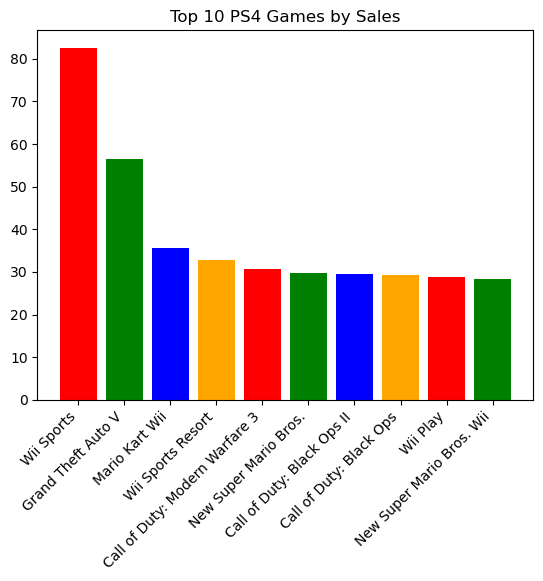

In [16]:
top_games = data.groupby("Name")["Global_Sales"].sum().sort_values(ascending=False).head(10)
colors = ["red", "green", "blue", "orange"]
plt.bar(top_games.index, top_games.values, color = colors)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 PS4 Games by Sales")
plt.show()


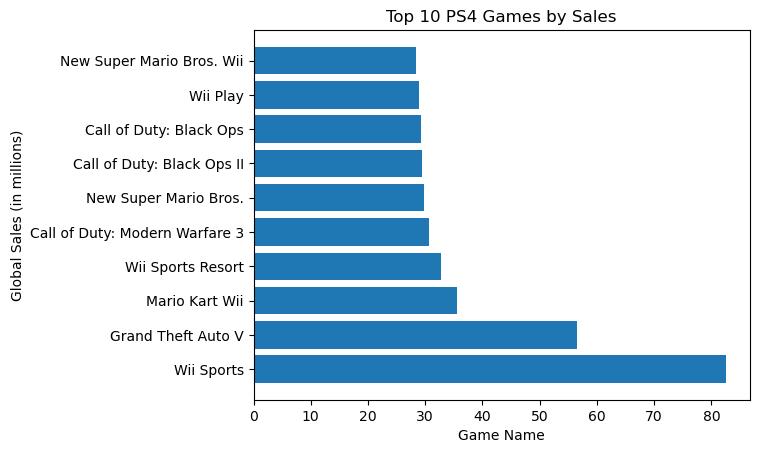

In [17]:
top_games = data.groupby("Name")["Global_Sales"].sum().sort_values(ascending=False).head(10)
plt.barh(top_games.index, top_games.values)
plt.title("Top 10 PS4 Games by Sales")
plt.xlabel("Game Name")
plt.ylabel("Global Sales (in millions)")
plt.show()

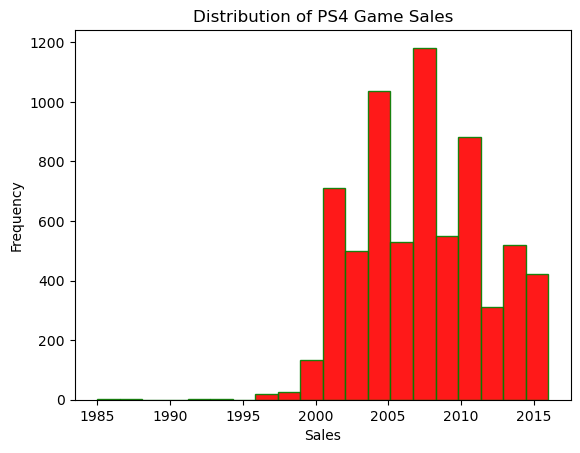

In [18]:
plt.hist(data["Year_of_Release"], bins=20, color='r', edgecolor='g' , alpha=0.9)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of PS4 Game Sales")
plt.show()


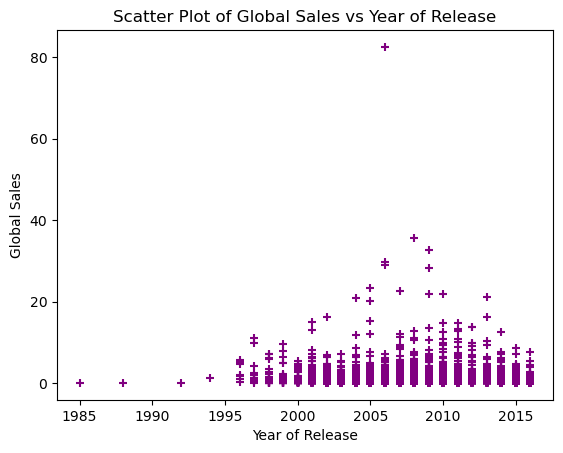

In [19]:
plt.scatter(data["Year_of_Release"], data["Global_Sales"],color = 'purple', marker='+')
plt.title("Scatter Plot of Global Sales vs Year of Release")
plt.xlabel("Year of Release")
plt.ylabel("Global Sales")
plt.show()

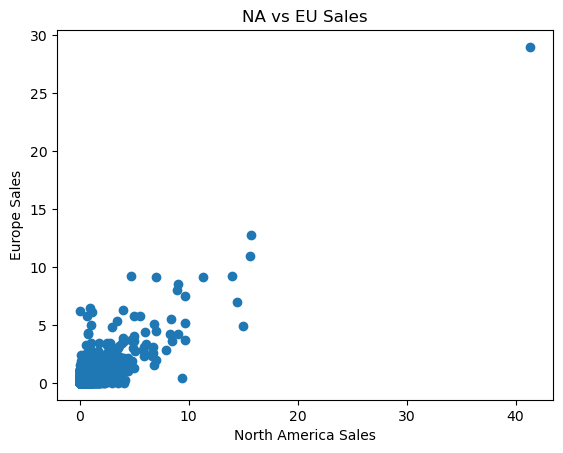

In [20]:
plt.scatter(data["NA_Sales"], data["EU_Sales"])
plt.xlabel("North America Sales")
plt.ylabel("Europe Sales")
plt.title("NA vs EU Sales")
plt.show()

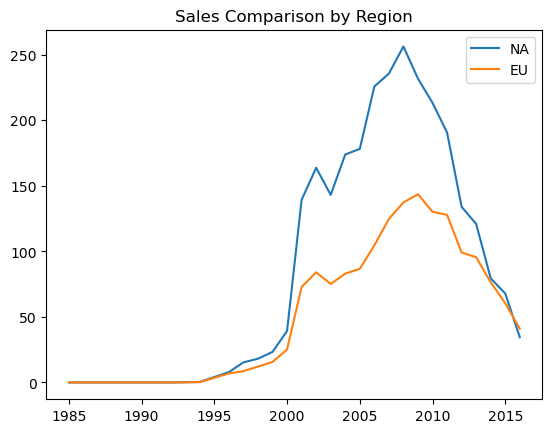

In [21]:
yearly = data.groupby("Year_of_Release")[["NA_Sales","EU_Sales"]].sum()

plt.plot(yearly.index, yearly["NA_Sales"], label="NA")
plt.plot(yearly.index, yearly["EU_Sales"], label="EU")
plt.legend()
plt.title("Sales Comparison by Region")
plt.show()


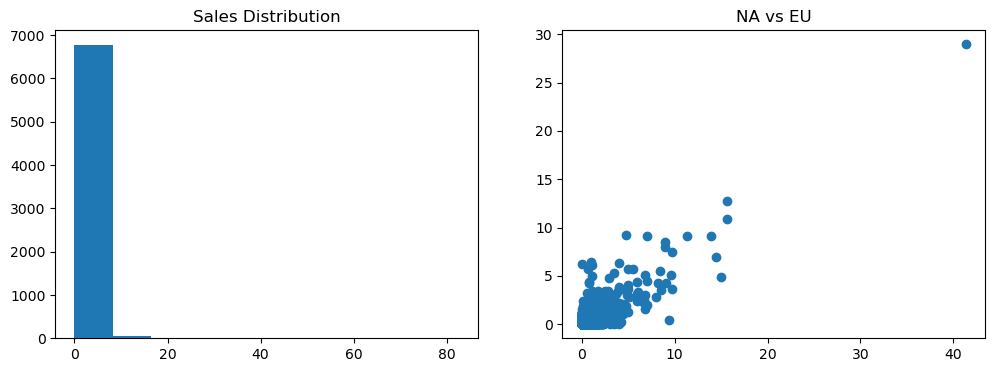

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].hist(data["Global_Sales"])
ax[0].set_title("Sales Distribution")

ax[1].scatter(data["NA_Sales"], data["EU_Sales"])
ax[1].set_title("NA vs EU")

plt.show()


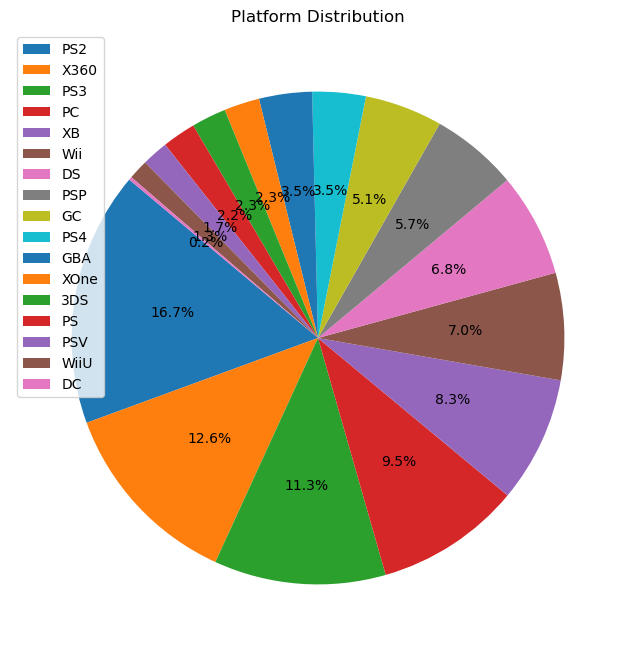

In [23]:
plt.figure(figsize=(8,8))
plt.pie(data["Platform"].value_counts(), autopct='%1.1f%%', startangle=140)
plt.title("Platform Distribution")
plt.legend(data["Platform"].value_counts().index, loc="best")
plt.show()

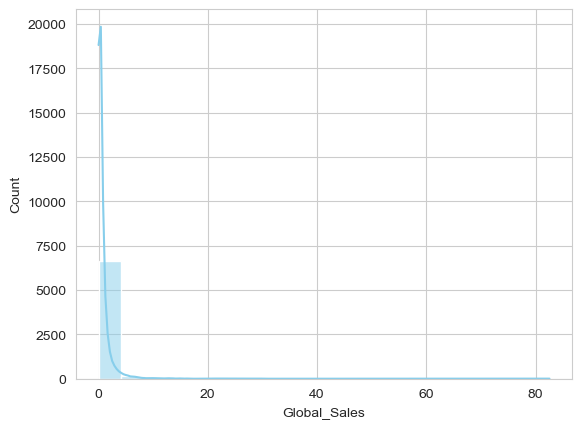

In [36]:
import seaborn as sns
sns.set_style("whitegrid")
sns.histplot(data["Global_Sales"], bins=20, kde=True, color='skyblue')
plt.show()

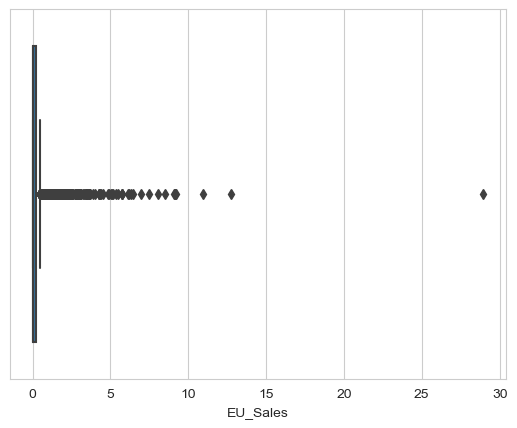

In [38]:
sns.boxplot(x=data["EU_Sales"])
plt.show()
